In [1]:
!pip install --upgrade datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 28.8 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import math
import pickle
from datasets import load_dataset
import regex
from tqdm import tqdm
import os
import json
import time
import numpy as np
from collections import defaultdict
from transformers import AutoTokenizer

**Testing the GPU availability**

In [3]:
print(torch.cuda.is_available())  # Should return True
print(torch.cuda.get_device_name(0))


True
Tesla T4


Prepring the training data

In [3]:
num_documents=500 # Define the number of documents to load
# Print a loading message
print(f"Loading HuggingFaceTB/smollm-corpus dataset (cosmopedia-v2)...")
# Load a pre-trained tokenizer
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM-135M", token=False)

# --------  Load the dataset in streaming mode. ----------------
# Cosmopedia v2 is an enhanced version of Cosmopedia, the largest synthetic
#dataset for pre-training, consisting of over 39 million textbooks, blog posts, and stories
# The foillowing line of code is taken from huggingface HuggingFaceTB/smollm-corpus page.

dataset = load_dataset("HuggingFaceTB/smollm-corpus", "cosmopedia-v2", split="train", streaming=True, token=False)



texts = [] # Initialize an empty list to store the loaded texts
for i, item in enumerate(dataset): # Iterate through the dataset items
    if i >= num_documents: # Check if the desired number of documents has been loaded
        break # Exit the loop if enough documents are loaded
    texts.append(item["text"]) # Add the 'text' field of the current item to the texts list

print(f"Loaded {len(texts)} documents") # Print the number of documents loaded
total_tokens = sum(len(tokenizer.encode(text)) for text in texts) # Calculate the total number of tokens across all documents
print(f"Total tokens: {total_tokens:,}") # Print the total number of tokens
words_cnt = sum(len(text.split()) for text in texts)
print(f"Total words:{words_cnt:,}")
print(f"Average tokens per document: {total_tokens / len(texts):.1f}") # Print the average number of tokens per document

#--- printing above  numbers ------
# --------Advanced Formatting Techniques ----
'''
---F-Strings (Recommended): ----
  Use a prefix f and curly braces {} to embed variables.
  You can specify fixed-point precision for floats using : .nf.

  pi = 3.14159
  print(f"Pi to 2 decimal places is {pi:.2f}")  # Output: Pi to 2 decimal places is 3.14


--- Thousands Separators: --------
  Use the :, specifier within an f-string to make large numbers more readable.

  print(f"Total: {1000000:,}")  # Output: Total: 1,000,000


'''



Loading HuggingFaceTB/smollm-corpus dataset (cosmopedia-v2)...


config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer.json: 0.00B [00:00, ?B/s]

...

Resolving data files:   0%|          | 0/104 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/104 [00:00<?, ?it/s]

'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/HuggingFaceTB/smollm-corpus/resolve/3ba9d605774198c5868892d7a8deda78031a781f/cosmopedia-v2/train-00000-of-00104.parquet
Retrying in 1s [Retry 1/5].


Loaded 500 documents
Total tokens: 366,493
Total words:277,221
Average tokens per document: 733.0


'\n---F-Strings (Recommended): ----\n  Use a prefix f and curly braces {} to embed variables. \n  You can specify fixed-point precision for floats using : .nf.\n\n  pi = 3.14159\n  print(f"Pi to 2 decimal places is {pi:.2f}")  # Output: Pi to 2 decimal places is 3.14\n\n\n--- Thousands Separators: --------\n  Use the :, specifier within an f-string to make large numbers more readable.\n\n  print(f"Total: {1000000:,}")  # Output: Total: 1,000,000\n\n\n'

In [4]:
tokenizer

TokenizersBackend(name_or_path='HuggingFaceTB/SmolLM-135M', vocab_size=49152, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>'}, added_tokens_decoder={
	0: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<|im_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<|im_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<repo_name>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("<reponame>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	5: AddedToken("<file_sep>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	6: AddedToken("<filename>", rstrip

In [5]:
dataset

IterableDataset({
    features: ['prompt', 'text', 'token_length', 'audience', 'format', 'seed_data'],
    num_shards: 104
})

In [6]:
texts

[" In today's ever-evolving world, technology has become an integral part of our lives, shaping the way we learn, work, and communicate. The COVID-19 pandemic has only accelerated this trend, forcing educational institutions worldwide to adapt quickly to remote learning models. As such, social studies integration in elementary education can greatly benefit from incorporating digital tools like those offered by Ruangguru's Online School. Let's explore how educators can effectively leverage these resources to create engaging and meaningful learning experiences for young students.\n\nFirstly, let's define what we mean by social studies integration. Social studies encompasses various disciplines that help students understand their communities, societies, and the wider world around them. These subjects may include history, geography, civics, economics, sociology, and anthropology. By integrating social studies into the curriculum, we aim to foster critical thinking skills, promote cultural 

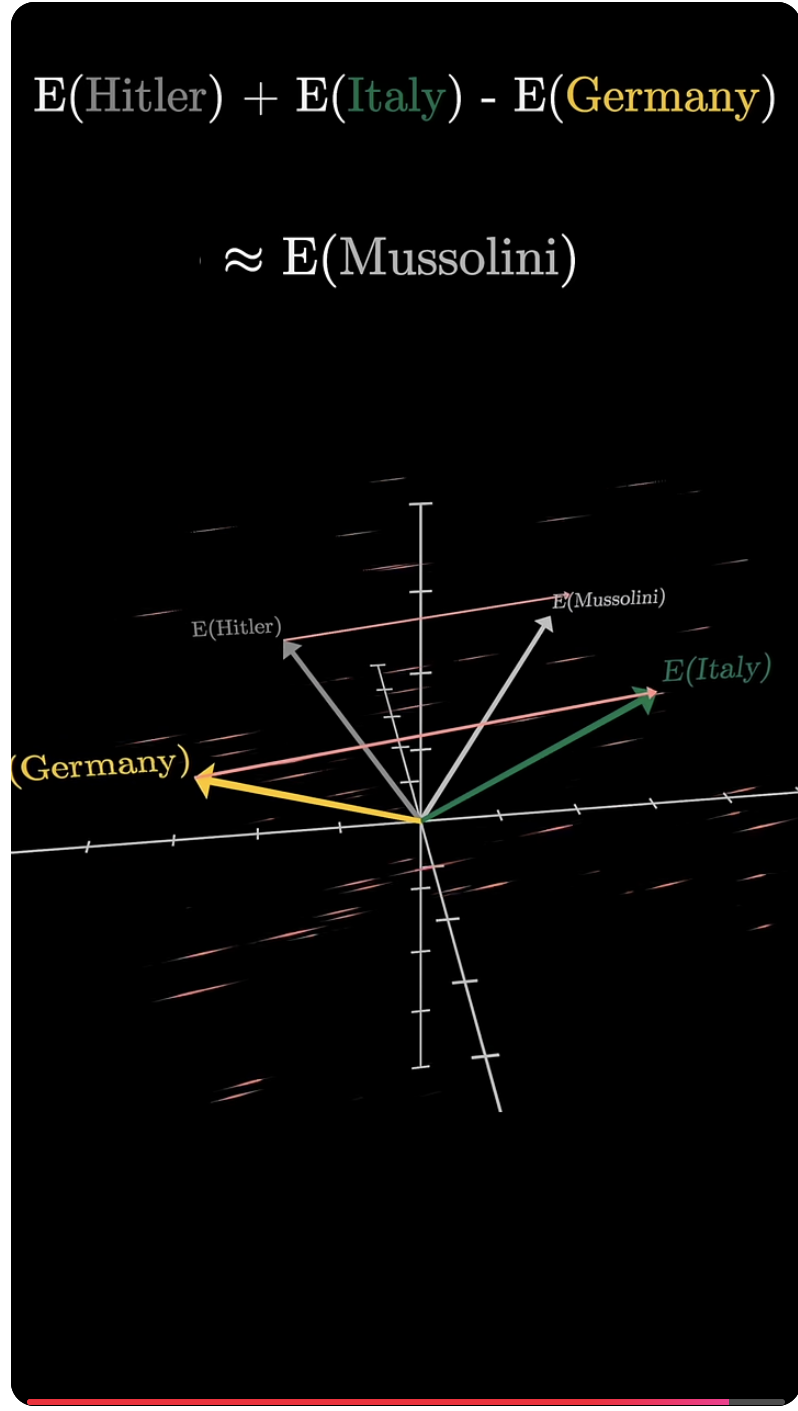

In [7]:
texts[0]

" In today's ever-evolving world, technology has become an integral part of our lives, shaping the way we learn, work, and communicate. The COVID-19 pandemic has only accelerated this trend, forcing educational institutions worldwide to adapt quickly to remote learning models. As such, social studies integration in elementary education can greatly benefit from incorporating digital tools like those offered by Ruangguru's Online School. Let's explore how educators can effectively leverage these resources to create engaging and meaningful learning experiences for young students.\n\nFirstly, let's define what we mean by social studies integration. Social studies encompasses various disciplines that help students understand their communities, societies, and the wider world around them. These subjects may include history, geography, civics, economics, sociology, and anthropology. By integrating social studies into the curriculum, we aim to foster critical thinking skills, promote cultural a

In [8]:
len(texts)

500

In [9]:
#num_documents=500  as the number of documents to load

In [10]:
type(dataset)

datasets.iterable_dataset.IterableDataset

In [11]:
'''
The first 5 records of the dataset are printed below. Each record is a dictionary
containing fields like 'prompt', 'text', 'token_length', 'audience', and 'format'.
'''

for i, record in enumerate(dataset.take(5)):
    print(f'--- Record {i+1} ---')
    print(record)
    print('\n')

'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/HuggingFaceTB/smollm-corpus/resolve/3ba9d605774198c5868892d7a8deda78031a781f/cosmopedia-v2/train-00000-of-00104.parquet
Retrying in 1s [Retry 1/5].
'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/HuggingFaceTB/smollm-corpus/resolve/3ba9d605774198c5868892d7a8deda78031a781f/cosmopedia-v2/train-00000-of-00104.parquet
Retrying in 1s [Retry 1/5].
'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/HuggingFaceTB/smollm-corpus/resolve/3ba9d605774198c5868892d7a8deda78031a781f/cosmopedia-v2/train-00000-of-00104.parquet
Retrying in 2s [Retry 2/5].
'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/HuggingFaceTB/smollm-corpus/resolve/3ba9d605774198c5868892d7a8deda78031a781f/cosmopedia-v2/train-00000-of-00104.parquet
Retrying in 4s [Retry 3/5].
'The read operation timed out' thrown while 

--- Record 1 ---
{'prompt': 'Here is an extract from a webpage:\n"Ruangguru Free Online Schools to Support Students and Teachers\nRuangguru re-opened Ruangguru Online School for free through its application. This is a form and effort of Ruangguru in responding to the high need for distance learning facilities (PJJ) during the Covid-19 pandemic.\nPreviously, since March 2020 when learning activities from home were implemented due to Covid-19, Ruangguru has launched the free Ruangguru Online School.\nIn the past school year, the Ruangguru Online School received a positive response with more than 5,000,000 students using it. More than 100,000 teachers have also participated in free online teacher training provided on the Ruangguru app.\nThe enthusiasm of the teachers and students to continue learning inspires us to re-open the Ruangguru Free Online School, “explained Ruangguru’s founder and Chief Director, Belva Devara, as quoted from his official statement on Monday (3/8/2020).\nRuanggur

In [12]:
# ---- load_smollm_corpus(num_documents=500) ------


# print all the fields of a dataset
print(f"Fields in the dataset: {list(dataset.features.keys())}")

# print each field of 1st record of dataset
first_record = next(iter(dataset))
for field, value in first_record.items():
    print(f"--- {field} ---")
    print(value)
    print()

Fields in the dataset: ['prompt', 'text', 'token_length', 'audience', 'format', 'seed_data']


'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/HuggingFaceTB/smollm-corpus/resolve/3ba9d605774198c5868892d7a8deda78031a781f/cosmopedia-v2/train-00000-of-00104.parquet
Retrying in 1s [Retry 1/5].
'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/HuggingFaceTB/smollm-corpus/resolve/3ba9d605774198c5868892d7a8deda78031a781f/cosmopedia-v2/train-00000-of-00104.parquet
Retrying in 2s [Retry 2/5].
'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/HuggingFaceTB/smollm-corpus/resolve/3ba9d605774198c5868892d7a8deda78031a781f/cosmopedia-v2/train-00000-of-00104.parquet
Retrying in 1s [Retry 1/5].
'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/HuggingFaceTB/smollm-corpus/resolve/3ba9d605774198c5868892d7a8deda78031a781f/cosmopedia-v2/train-00000-of-00104.parquet
Retrying in 1s [Retry 1/5].


--- prompt ---
Here is an extract from a webpage:
"Ruangguru Free Online Schools to Support Students and Teachers
Ruangguru re-opened Ruangguru Online School for free through its application. This is a form and effort of Ruangguru in responding to the high need for distance learning facilities (PJJ) during the Covid-19 pandemic.
Previously, since March 2020 when learning activities from home were implemented due to Covid-19, Ruangguru has launched the free Ruangguru Online School.
In the past school year, the Ruangguru Online School received a positive response with more than 5,000,000 students using it. More than 100,000 teachers have also participated in free online teacher training provided on the Ruangguru app.
The enthusiasm of the teachers and students to continue learning inspires us to re-open the Ruangguru Free Online School, “explained Ruangguru’s founder and Chief Director, Belva Devara, as quoted from his official statement on Monday (3/8/2020).
Ruangguru Online School 2 fo

In [13]:
dataset.features.keys()

dict_keys(['prompt', 'text', 'token_length', 'audience', 'format', 'seed_data'])

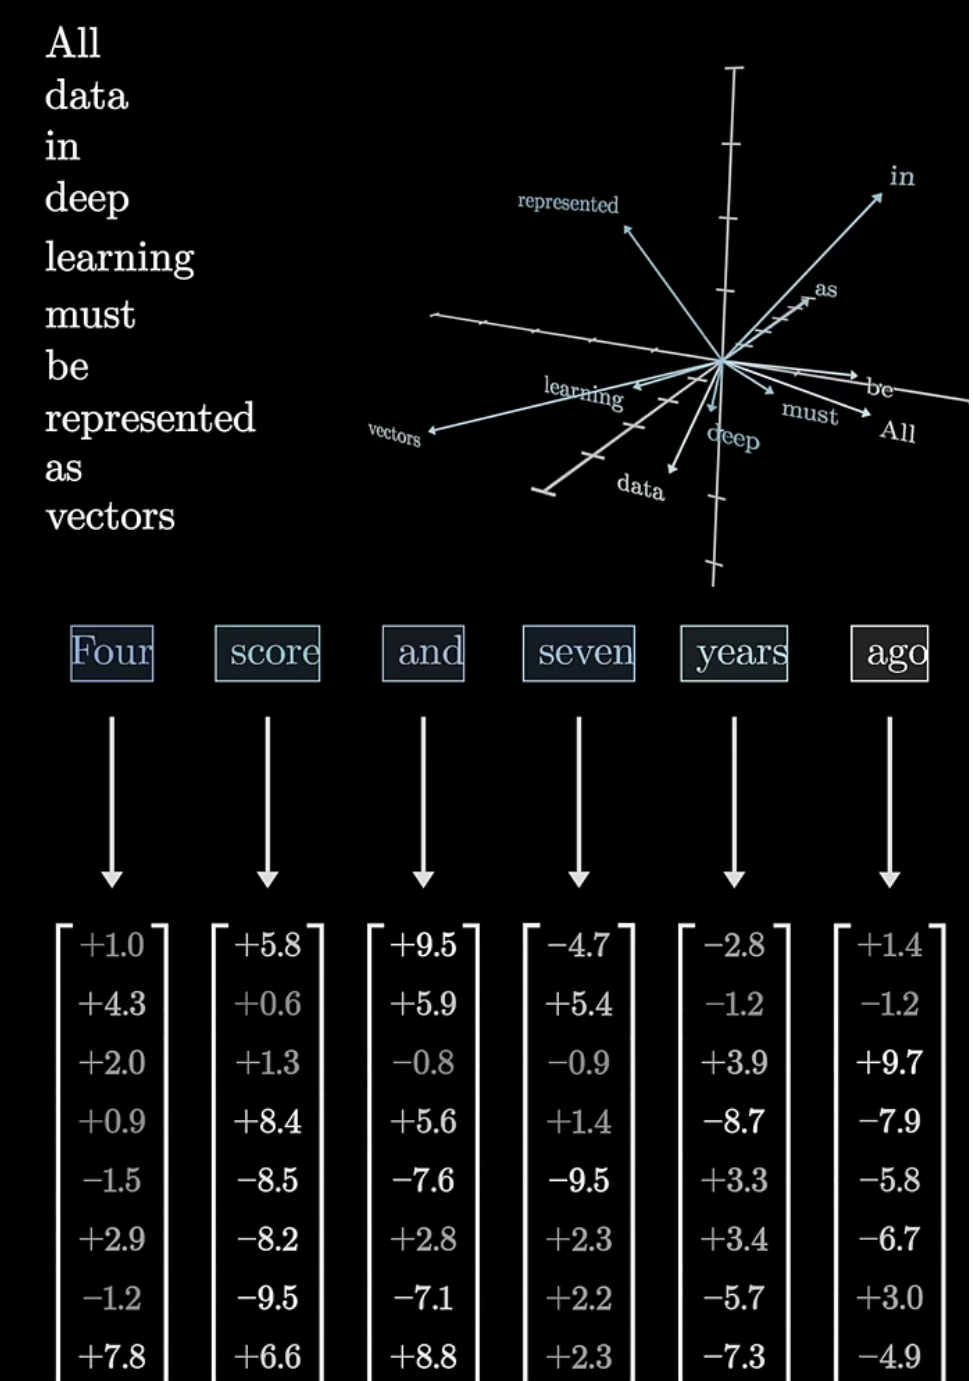

In [15]:
# ---- TextTokenDataset(Dataset) -------

tokenizer = tokenizer# from above code
seq_len = 512

print("Tokenizing texts...")
all_tokens = []
for text in tqdm(texts, desc="Tokenizing"):
        tokens = tokenizer.encode(text)
        all_tokens.extend(tokens)

tokens = all_tokens
print(f"\nTotal tokens after concatenation: {len(tokens):,}")

Tokenizing texts...


Tokenizing: 100%|██████████| 500/500 [00:01<00:00, 294.52it/s]


Total tokens after concatenation: 366,493


In [ ]:
# ---- TextTokenDataset(Dataset) -------

# Re-assign the pre-trained tokenizer from the previous steps
tokenizer = tokenizer

# Define the maximum sequence length for the model input
seq_len = 512

print("Tokenizing texts...")

# Initialize an empty list to accumulate tokens from all documents
all_tokens = []

# Iterate through each text document with a tqdm progress bar for visual feedback
for text in tqdm(texts, desc="Tokenizing"):
    # Encode the text string into a list of integer token IDs
    tokens_list = tokenizer.encode(text)
    # Extend the master list with the tokens from the current document
    all_tokens.extend(tokens_list)

# Assign the concatenated result back to the 'tokens' variable
tokens = all_tokens

# Print the final count of tokens processed across all documents
print(f"\nTotal tokens after concatenation: {len(tokens):,}")


x = torch.tensor(tokens[idx:idx + seq_len], dtype=torch.long)
y = torch.tensor(tokens[idx + 1:idx + seq_len + 1], dtype=torch.long)

Tokenizing texts...


Tokenizing: 100%|██████████| 500/500 [00:01<00:00, 294.52it/s]


Total tokens after concatenation: 366,493


In [16]:
type(tokens)

list

In [17]:
tokens[0]

533

In [18]:
tokens[:10]

[533, 1834, 506, 2042, 29, 24186, 905, 28, 1835, 553]

In [4]:

# Ablation configurations for Colab T4
COLAB_ABLATIONS = {
    'baseline': {},

    'small_model': {
        'd_model': 256,
        'n_heads': 4,
        'n_layers': 8,
        'd_ff': 256*4,
        'batch_size': 12,  # Can fit more
    },

    'high_lr': {
        'learning_rate': 1e-3,
    },

    'low_lr': {
        'learning_rate': 1e-4,
    },

    'large_batch': {
        'batch_size': 16,
        'learning_rate': 5e-4,  # Scale with batch size
    },

    'short_seq': {
        'seq_len': 256,
        'batch_size': 12,
    },
}


In [5]:
"""Run ablations suitable for Colab T4"""
results = {}

for config_name, custom_config in COLAB_ABLATIONS.items():
        print(f"\n{'='*60}")
        print(f"🔬 ABLATION: {config_name.upper()}")
        print(f"{'='*60}")

'''

        try:
            model, tracker = train_with_comprehensive_logging(config_name, custom_config)
            results[config_name] = tracker

            # Clear GPU memory
            del model
            torch.cuda.empty_cache()

        except Exception as e:
            print(f"❌ Failed ablation {config_name}: {e}")
            torch.cuda.empty_cache()
            continue

print(f"\n🎉 Completed {len(results)} ablations!")
'''

#return results



🔬 ABLATION: BASELINE

🔬 ABLATION: SMALL_MODEL

🔬 ABLATION: HIGH_LR

🔬 ABLATION: LOW_LR

🔬 ABLATION: LARGE_BATCH

🔬 ABLATION: SHORT_SEQ


'\n\n        try:\n            model, tracker = train_with_comprehensive_logging(config_name, custom_config)\n            results[config_name] = tracker\n\n            # Clear GPU memory\n            del model\n            torch.cuda.empty_cache()\n\n        except Exception as e:\n            print(f"❌ Failed ablation {config_name}: {e}")\n            torch.cuda.empty_cache()\n            continue\n\nprint(f"\n🎉 Completed {len(results)} ablations!")\n'

In [3]:
config_name

'short_seq'

In [29]:
# custom_config holds the specific parameters for the current ablation experiment.
# In the current state, it contains the settings for 'short_seq'.
custom_config

{'seq_len': 256, 'batch_size': 12}

In [ ]:
"""Enhanced training with comprehensive metrics logging"""

# Default configuration
config = {
        'seq_len': 512,
        'd_model': 384,
        'n_heads': 6,
        'n_layers': 12,
        'd_ff': 384*4,
        'batch_size': 8,
        'learning_rate': 3e-4,
        'epochs': 1,
        'warmup_steps': 1000,
        'cooldown_frac': 0.4,

        'eval_every': 400,
        'use_amp': True,
        'num_documents': 500,
        'max_steps': 2000,  # Limit for Colab
    }

# Override with custom config
if custom_config:
        config.update(custom_config)

print(f"🚀 Starting training: {config_name}")
print(f"📋 Config: {config}")

# Initialize metrics tracker
tracker = EnhancedMetricsTracker(save_dir=f"training_logs/{config_name}")

# Load data
texts, tokenizer = load_smollm_corpus(num_documents=config['num_documents'])
vocab_size = tokenizer.vocab_size

# Create datasets
dataset = TextTokenDataset(texts, tokenizer, config['seq_len'])

# Split into train/val
val_size = len(dataset) // 10
train_size = len(dataset) - val_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)

# Initialize model
model = MinimalLLM(
        vocab_size=vocab_size,
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        n_layers=config['n_layers'],
        d_ff=config['d_ff'],
        max_len=config['seq_len']
    )

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Compile model
try:
        model = torch.compile(model, mode='default')
        print("✅ Model compiled successfully!")
except Exception as e:
        print(f"⚠️ torch.compile failed: {e}")


**Why SmoLLM?**

SmoLLM models are optimized through a combination of advanced training techniques that aim to maximize their efficiency while reducing their complexity. Among these techniques, Model distillation is often used to transfer knowledge from a large language model to a smaller model without sacrificing performance.

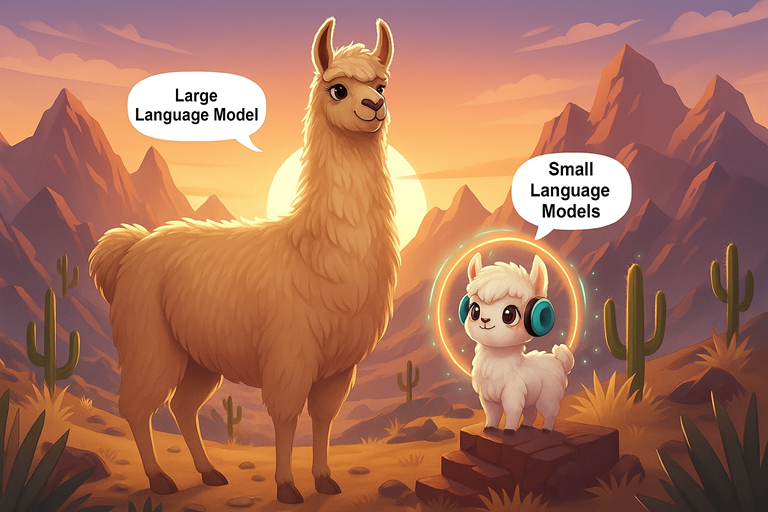

In [6]:
# Default configuration
config = {
        'seq_len': 512,
        'd_model': 384,
        'n_heads': 6,
        'n_layers': 12,
        'd_ff': 384*4,
        'batch_size': 8,
        'learning_rate': 3e-4,
        'epochs': 1,
        'warmup_steps': 1000,
        'cooldown_frac': 0.4,

        'eval_every': 400,
        'use_amp': True,
        'num_documents': 500,
        'max_steps': 2000,  # Limit for Colab
    }



if custom_config:
        config.update(custom_config)

In [7]:
print(f"🚀 Starting training: {config_name}")
print(f"📋 Config: {config}")

🚀 Starting training: short_seq
📋 Config: {'seq_len': 256, 'd_model': 384, 'n_heads': 6, 'n_layers': 12, 'd_ff': 1536, 'batch_size': 12, 'learning_rate': 0.0003, 'epochs': 1, 'warmup_steps': 1000, 'cooldown_frac': 0.4, 'eval_every': 400, 'use_amp': True, 'num_documents': 500, 'max_steps': 2000}


In [8]:
#----- load_smollm_corpus()----

num_documents=500

"""Load SmolLM corpus data for autoregressive training"""
print(f"Loading HuggingFaceTB/smollm-corpus dataset (cosmopedia-v2)...")
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM-135M", token=False)
dataset = load_dataset("HuggingFaceTB/smollm-corpus", "cosmopedia-v2", split="train", streaming=True, token=False)

texts = []
for i, item in enumerate(dataset):
    if i >= num_documents:
        break
    texts.append(item["text"])

print(f"Loaded {len(texts)} documents")
total_tokens = sum(len(tokenizer.encode(text)) for text in texts)
print(f"Total tokens: {total_tokens:,}")
print(f"Average tokens per document: {total_tokens / len(texts):.1f}")

#return texts, tokenizer

Loading HuggingFaceTB/smollm-corpus dataset (cosmopedia-v2)...


config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/104 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/104 [00:00<?, ?it/s]

Loaded 500 documents
Total tokens: 366,493
Average tokens per document: 733.0


In [9]:
vocab_size = tokenizer.vocab_size





In [12]:
# Create datasets
#dataset = TextTokenDataset(texts, tokenizer, config['seq_len'])


#class TextTokenDataset(Dataset):
seq_len=512
#def __init__(self, texts, tokenizer, seq_len=512):
tokenizer = tokenizer
seq_len = 512

print("Tokenizing texts...")
all_tokens = []
for text in tqdm(texts, desc="Tokenizing"):
        tokens = tokenizer.encode(text)
        all_tokens.extend(tokens)

tokens = all_tokens
print(f"Total tokens after concatenation: {len(tokens):,}")

'''
    def __len__(self):
        return len(self.tokens) - self.seq_len

    def __getitem__(self, idx):
        x = torch.tensor(self.tokens[idx:idx + self.seq_len], dtype=torch.long)
        y = torch.tensor(self.tokens[idx + 1:idx + self.seq_len + 1], dtype=torch.long)
        return x, y

'''

Tokenizing texts...


Tokenizing: 100%|██████████| 500/500 [00:01<00:00, 473.42it/s]

Total tokens after concatenation: 366,493


'\n    def __len__(self):\n        return len(self.tokens) - self.seq_len\n\n    def __getitem__(self, idx):\n        x = torch.tensor(self.tokens[idx:idx + self.seq_len], dtype=torch.long)\n        y = torch.tensor(self.tokens[idx + 1:idx + self.seq_len + 1], dtype=torch.long)\n        return x, y\n\n'

In [13]:
# def __len__(self):
len(tokens) - seq_len

365981

In [14]:
#def __getitem__(self, idx):
idx=10 # this is a hypothetical number. 'idx' is an input parameter as above.
x = torch.tensor(tokens[idx:idx + seq_len], dtype=torch.long)
y = torch.tensor(tokens[idx + 1:idx + seq_len + 1], dtype=torch.long)


In [15]:
x

tensor([ 1438,   354, 10021,   599,   282,   653,  2397,    28,  5929,   260,
          970,   392,   835,    28,   746,    28,   284,  5865,    30,   378,
         7191,    29,    33,    41,  8832,   553,   805, 18438,   451,  4213,
           28, 14072,  4096,  4679,  4969,   288,  2930,  3112,   288,  6431,
         1380,  2859,    30,  1032,   715,    28,  1329,  2157,  7657,   281,
        11289,  1888,   416,  6899,  3724,   429,  6457,  3182,  2549,   702,
          967,  5340,   411, 20139,   604,    87, 16634,   506,  8646,  3056,
           30,  2959,   506,  2217,   638,  7537,   416,  4025, 17188,   623,
         1952,   288,  1464,  4798,   284,  6579,  1380,  2647,   327,  1805,
         1058,    30,   198,   198, 21028,    28,  1303,   506,  5879,   732,
          392,  1441,   411,  1329,  2157,  7657,    30,  4758,  2157, 15868,
         1461, 10578,   338,   724,  1058,  1044,   480,  2429,    28,  6815,
           28,   284,   260,  9376,   905,  1130,   601,    30, 

In [16]:
# Split into train/val
val_size = len(dataset) // 10
train_size = len(dataset) - val_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])


TypeError: object of type 'IterableDataset' has no len()

In [24]:
class TextTokenDataset(Dataset):
    def __init__(self, texts, tokenizer, seq_len=512):
        self.tokenizer = tokenizer
        self.seq_len = seq_len

        print("Tokenizing texts...")
        all_tokens = []
        for text in tqdm(texts, desc="Tokenizing"):
            tokens = tokenizer.encode(text)
            all_tokens.extend(tokens)

        self.tokens = all_tokens
        print(f"Total tokens after concatenation: {len(self.tokens):,}")

    '''
    Inside your TextTokenDataset class, you defined a special method called __len__:

    def __len__(self):
      return len(self.tokens) - self.seq_len

      When you call len(dataset), Python looks for this specific method.
    It takes the total number of tokens you extracted (366,493) and subtracts the
    sequence length (512 or 256 depending on config), giving you the final result
    of 366,237.

    This makes it a Map-style dataset, which allows PyTorch to easily split the data
    and access any item by its index.
    '''
    def __len__(self):
        return len(self.tokens) - self.seq_len

    def __getitem__(self, idx):
        x = torch.tensor(self.tokens[idx:idx + self.seq_len], dtype=torch.long)
        y = torch.tensor(self.tokens[idx + 1:idx + self.seq_len + 1], dtype=torch.long)
        return x, y

In [18]:
dataset = TextTokenDataset(texts, tokenizer, config['seq_len'])

Tokenizing texts...


Tokenizing: 100%|██████████| 500/500 [00:02<00:00, 167.25it/s]

Total tokens after concatenation: 366,493


In [19]:
dataset

In [20]:
val_size = len(dataset) // 10

In [21]:
val_size

36623

In [22]:
type(dataset)

__main__.TextTokenDataset

In [23]:
len(dataset)

366237

In [27]:
366493-256

366237

In [26]:
config['seq_len']

256